# 1. Does Carbohydrate Intake Increase Glucose Levels?
## Markers Used:
 carb_input
 glucose
 bolus_vol
## Reasoning:
Carbohydrates are the primary source of glucose increase in T1DM patients. After meals, glucose levels rise, and bolus insulin is administered to control post-meal spikes.
## This analysis helps determine:
Whether higher carbohydrate intake causes higher glucose levels.
Whether insulin dosing is sufficient after meals.
This is clinically important because uncontrolled post-meal glucose spikes increase the risk of hyperglycemia.

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Load cleaned dataset
df = pd.read_csv(r"C:\Users\Pravallika Dheshidi\OneDrive\Documents\GitHub\team9_PyCoders_PythonHackathon_MAY2026\cleaned_data.csv")

In [7]:
# First, check what columns are available in the DataFrame
print("Available columns:")
print(df.columns.tolist())

Available columns:
['time', 'glucose', 'calories', 'heart_rate', 'steps', 'basal_rate', 'bolus_volume_delivered', 'carb_input', 'Patient_ID', 'Age', 'Gender', 'Race', 'Average Sleep Duration (hrs)', 'Sleep Quality (1-10)', '% with Sleep Disturbances']


In [8]:
print(df[['carb_input', 'glucose', 'bolus_volume_delivered']].corr())

                        carb_input   glucose  bolus_volume_delivered
carb_input                1.000000 -0.001014                0.169899
glucose                  -0.001014  1.000000                0.020115
bolus_volume_delivered    0.169899  0.020115                1.000000


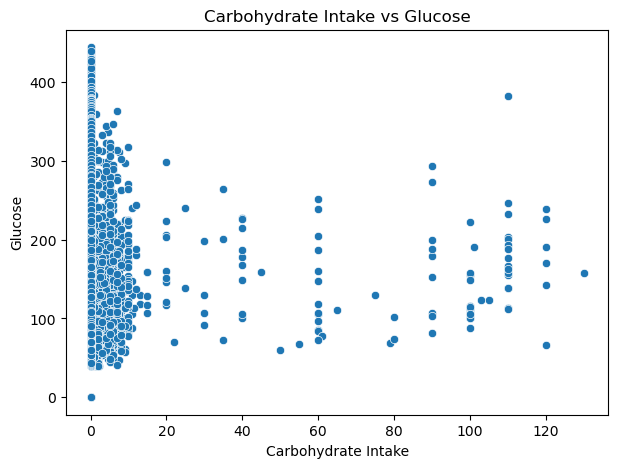

In [10]:
# Scatterplot
plt.figure(figsize=(7,5))
sns.scatterplot(x='carb_input', y='glucose', data=df)
plt.title("Carbohydrate Intake vs Glucose")
plt.xlabel("Carbohydrate Intake")
plt.ylabel("Glucose")
plt.show()

# 2.Does Poor Sleep Affect Glucose Stability?
## Markers Used
Sleep Qua
% with Sleep Disturbances
glucose
## Reasoning
Sleep quality affects:
Hormone regulation
Stress response
Insulin sensitivity
Poor sleep can increase glucose variability and worsen diabetes management.
This analysis helps determine whether sleep disturbances contribute to unstable glucose patterns.

                           Sleep Quality (1-10)  % with Sleep Disturbances  \
Sleep Quality (1-10)                   1.000000                  -0.280085   
% with Sleep Disturbances             -0.280085                   1.000000   
glucose                               -0.085434                   0.011126   

                            glucose  
Sleep Quality (1-10)      -0.085434  
% with Sleep Disturbances  0.011126  
glucose                    1.000000  


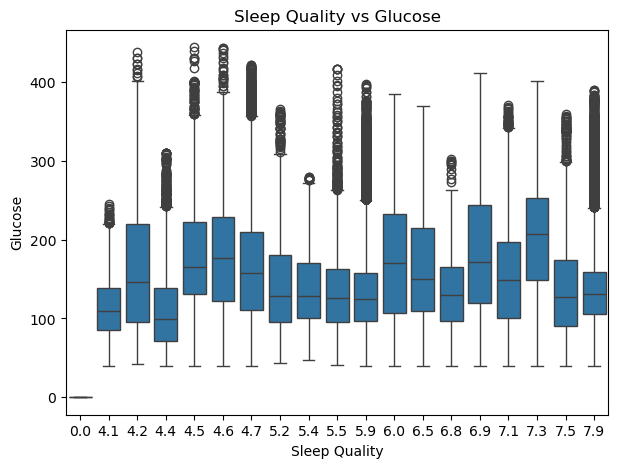

In [12]:
sleep_cols = ['Sleep Quality (1-10)', '% with Sleep Disturbances', 'glucose']

# Correlation
print(df[sleep_cols].corr())

# Boxplot
plt.figure(figsize=(7,5))
sns.boxplot(x='Sleep Quality (1-10)', y='glucose', data=df)
plt.title("Sleep Quality vs Glucose")
plt.xlabel("Sleep Quality")
plt.ylabel("Glucose")
plt.show()

# 3.Does Heart Rate Indicate Glucose Fluctuations?
## Markers Used
heart_rate
glucose
## Reasoning
## Heart rate reflects:
Physical activity
Stress response
Physiological exertion
Stress hormones such as cortisol and adrenaline can increase glucose levels, while exercise-related heart rate increases may lower glucose.

This analysis helps determine whether heart rate changes are associated with glucose variability.

            heart_rate   glucose
heart_rate    1.000000  0.098517
glucose       0.098517  1.000000


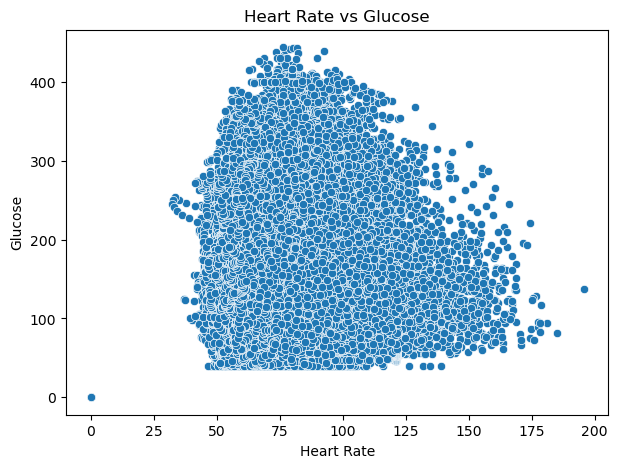

In [13]:
print(df[['heart_rate', 'glucose']].corr())

plt.figure(figsize=(7,5))
sns.scatterplot(x='heart_rate', y='glucose', data=df)

plt.title("Heart Rate vs Glucose")
plt.xlabel("Heart Rate")
plt.ylabel("Glucose")
plt.show()

# 4.Which Patients Show the Highest Average Glucose Levels?
## Markers Used
patient_id
glucose
## Reasoning
Different patients respond differently to:
Insulin
Activity
Sleep
Nutrition
## This analysis identifies:
High-risk patients
Patients requiring closer monitoring
Personalized treatment opportunities

Patient_ID
0.0            0.000000
HUPA0001P    181.443726
HUPA0002P    113.469660
HUPA0003P    143.273520
HUPA0004P    180.377984
HUPA0005P    147.698624
HUPA0006P    165.204585
HUPA0007P    173.151989
HUPA0009P    193.739271
HUPA0010P    135.892655
HUPA0011P    159.108578
HUPA0014P    188.061765
HUPA0015P    163.518724
HUPA0016P    150.208344
HUPA0017P    200.902387
HUPA0018P    143.677664
HUPA0019P    162.930477
HUPA0020P    194.282669
HUPA0021P    137.325152
HUPA0022P    112.550584
HUPA0023P    133.053330
HUPA0024P    166.943660
HUPA0025P    113.845607
HUPA0026P    162.985266
HUPA0027P    130.829946
HUPA0028P    128.436109
Name: glucose, dtype: float64


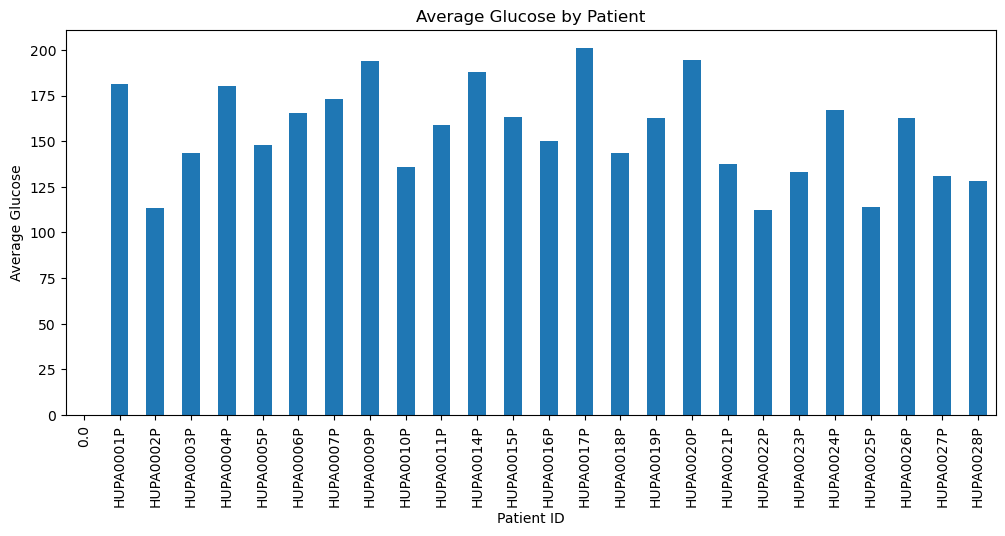

In [16]:
patient_avg = df.groupby('Patient_ID')['glucose'].mean()

print(patient_avg)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

patient_avg.plot(kind='bar')

plt.title("Average Glucose by Patient")
plt.xlabel("Patient ID")
plt.ylabel("Average Glucose")
plt.show()

In [17]:
print("Unique Patient_ID values:")
print(df['Patient_ID'].unique())

Unique Patient_ID values:
['HUPA0023P' 'HUPA0019P' 'HUPA0015P' 'HUPA0003P' 'HUPA0002P' 'HUPA0014P'
 'HUPA0018P' 'HUPA0022P' 'HUPA0005P' 'HUPA0025P' 'HUPA0009P' 'HUPA0024P'
 'HUPA0004P' 'HUPA0028P' 'HUPA0007P' 'HUPA0011P' 'HUPA0027P' 'HUPA0026P'
 'HUPA0010P' 'HUPA0006P' 'HUPA0021P' 'HUPA0001P' 'HUPA0017P' '0.0'
 'HUPA0016P' 'HUPA0020P']


In [15]:
print("Available columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())


Available columns: ['time', 'glucose', 'calories', 'heart_rate', 'steps', 'basal_rate', 'bolus_volume_delivered', 'carb_input', 'Patient_ID', 'Age', 'Gender', 'Race', 'Average Sleep Duration (hrs)', 'Sleep Quality (1-10)', '% with Sleep Disturbances']

First few rows:
                  time  glucose  calories  heart_rate  steps  basal_rate  \
0  2020-01-17 00:00:00    40.00     15.04       96.37    8.0       0.035   
1  2020-01-17 00:05:00    41.33      8.32       91.40    0.0       0.035   
2  2020-01-17 00:10:00    42.67      7.58       85.99    0.0       0.035   
3  2020-01-17 00:15:00    44.00      7.34       82.43    0.0       0.035   
4  2020-01-17 00:20:00    50.00      7.58       78.82    0.0       0.035   

   bolus_volume_delivered  carb_input Patient_ID  Age  Gender   Race  \
0                     0.0         1.0  HUPA0023P   74  Female  Black   
1                     0.0         0.0  HUPA0023P   74  Female  Black   
2                     0.0         0.0  HUPA0023P   74  Fem

In [18]:
# 3. Check for missing/null values
print(f"\nNumber of missing Patient_ID values: {df['Patient_ID'].isnull().sum()}")


Number of missing Patient_ID values: 0


In [19]:
# 6. Look at rows where Patient_ID might be problematic
print("\nRows with Patient_ID = 0.0:")
print(df[df['Patient_ID'] == 0.0][['Patient_ID', 'glucose', 'time']].head())


Rows with Patient_ID = 0.0:
Empty DataFrame
Columns: [Patient_ID, glucose, time]
Index: []


In [20]:
print("Checking for missing values:")
print(f"Number of NaN Patient_ID values: {df['Patient_ID'].isna().sum()}")
print(f"Number of null Patient_ID values: {df['Patient_ID'].isnull().sum()}")


Checking for missing values:
Number of NaN Patient_ID values: 0
Number of null Patient_ID values: 0


In [21]:
# 1. Check if there are actual numeric 0 values (not 0.0)
print("Checking for numeric zero values:")
print(f"Rows with Patient_ID == 0: {(df['Patient_ID'] == 0).sum()}")
print(f"Rows with Patient_ID == '0': {(df['Patient_ID'] == '0').sum()}")

# 2. Look at the actual Patient_ID values and their types
print(f"\nAll unique Patient_ID values:")
unique_vals = sorted(df['Patient_ID'].unique())
print(unique_vals)

# 3. Check if there are any whitespace or special character issues
print(f"\nChecking for whitespace issues:")
print(f"Patient_ID with only spaces: {(df['Patient_ID'].astype(str).str.strip() == '').sum()}")

# 4. Let's recreate the groupby and see exactly what's happening
print(f"\nRecreating the groupby operation:")
patient_avg_debug = df.groupby('Patient_ID')['glucose'].agg(['mean', 'count'])
print("Patient averages with counts:")
print(patient_avg_debug.head(10))

# 5. Check the first few rows of the original dataframe
print(f"\nFirst few rows to see Patient_ID values:")
print(df[['Patient_ID', 'glucose']].head(10))

# 6. Check data types more specifically
print(f"\nPatient_ID column info:")
print(df['Patient_ID'].dtype)
print(f"Sample values and their types:")
for i in range(min(5, len(df))):
    val = df['Patient_ID'].iloc[i]
    print(f"  {val} (type: {type(val)})")

Checking for numeric zero values:
Rows with Patient_ID == 0: 0
Rows with Patient_ID == '0': 0

All unique Patient_ID values:
['0.0', 'HUPA0001P', 'HUPA0002P', 'HUPA0003P', 'HUPA0004P', 'HUPA0005P', 'HUPA0006P', 'HUPA0007P', 'HUPA0009P', 'HUPA0010P', 'HUPA0011P', 'HUPA0014P', 'HUPA0015P', 'HUPA0016P', 'HUPA0017P', 'HUPA0018P', 'HUPA0019P', 'HUPA0020P', 'HUPA0021P', 'HUPA0022P', 'HUPA0023P', 'HUPA0024P', 'HUPA0025P', 'HUPA0026P', 'HUPA0027P', 'HUPA0028P']

Checking for whitespace issues:
Patient_ID with only spaces: 0

Recreating the groupby operation:
Patient averages with counts:
                  mean  count
Patient_ID                   
0.0           0.000000      4
HUPA0001P   181.443726   4096
HUPA0002P   113.469660   3181
HUPA0003P   143.273520   3770
HUPA0004P   180.377984   3184
HUPA0005P   147.698624   3858
HUPA0006P   165.204585   2290
HUPA0007P   173.151989   3857
HUPA0009P   193.739271   3812
HUPA0010P   135.892655   2976

First few rows to see Patient_ID values:
  Patient_I

In [22]:
# Look at the rows with Patient_ID = '0.0' (as string)
print("Rows with Patient_ID = '0.0' (string):")
problematic_rows = df[df['Patient_ID'] == '0.0']
print(f"Number of rows: {len(problematic_rows)}")
print(problematic_rows[['Patient_ID', 'glucose', 'time', 'Age', 'Gender']].head())

# Check if these rows have all zero glucose values
print(f"\nGlucose values for Patient_ID '0.0':")
print(problematic_rows['glucose'].tolist())

# To clean your data, you can filter out these rows:
print(f"\nTo remove these problematic rows:")
df_clean = df[df['Patient_ID'] != '0.0']
print(f"Original dataset size: {len(df)}")
print(f"Cleaned dataset size: {len(df_clean)}")

# Recalculate averages with clean data
patient_avg_clean = df_clean.groupby('Patient_ID')['glucose'].mean()
print(f"\nCleaned patient averages (first 5):")
print(patient_avg_clean.head())

Rows with Patient_ID = '0.0' (string):
Number of rows: 4
       Patient_ID  glucose time  Age Gender
299420        0.0      0.0  0.0    0    0.0
299990        0.0      0.0  0.0    0    0.0
301697        0.0      0.0  0.0    0    0.0
301991        0.0      0.0  0.0    0    0.0

Glucose values for Patient_ID '0.0':
[0.0, 0.0, 0.0, 0.0]

To remove these problematic rows:
Original dataset size: 309392
Cleaned dataset size: 309388

Cleaned patient averages (first 5):
Patient_ID
HUPA0001P    181.443726
HUPA0002P    113.469660
HUPA0003P    143.273520
HUPA0004P    180.377984
HUPA0005P    147.698624
Name: glucose, dtype: float64


Clean dataset: 309388 rows (removed 4 invalid rows)
Patient_ID
HUPA0001P    181.443726
HUPA0002P    113.469660
HUPA0003P    143.273520
HUPA0004P    180.377984
HUPA0005P    147.698624
HUPA0006P    165.204585
HUPA0007P    173.151989
HUPA0009P    193.739271
HUPA0010P    135.892655
HUPA0011P    159.108578
HUPA0014P    188.061765
HUPA0015P    163.518724
HUPA0016P    150.208344
HUPA0017P    200.902387
HUPA0018P    143.677664
HUPA0019P    162.930477
HUPA0020P    194.282669
HUPA0021P    137.325152
HUPA0022P    112.550584
HUPA0023P    133.053330
HUPA0024P    166.943660
HUPA0025P    113.845607
HUPA0026P    162.985266
HUPA0027P    130.829946
HUPA0028P    128.436109
Name: glucose, dtype: float64


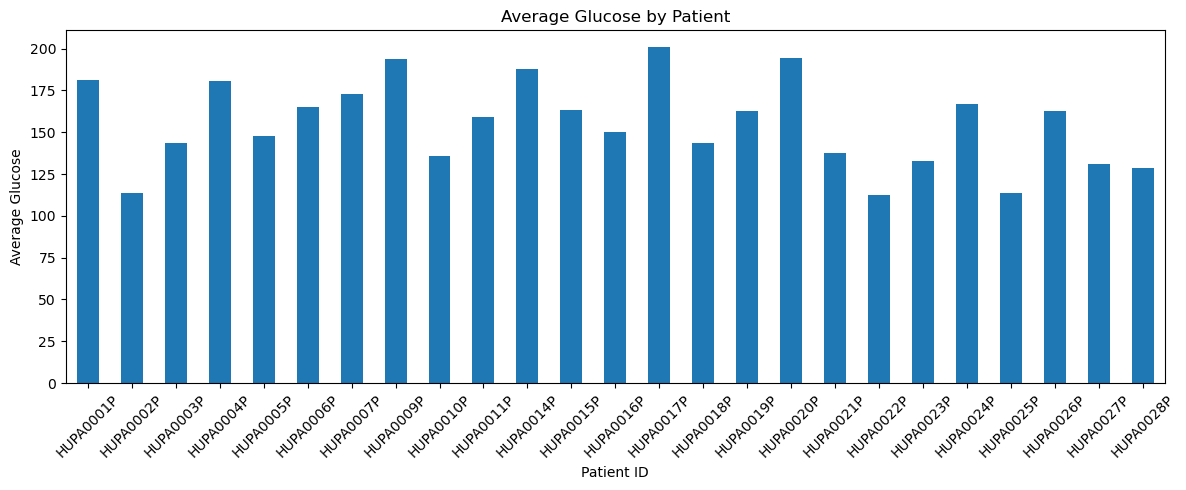

In [23]:
# Remove invalid rows with Patient_ID = '0.0'
df_clean = df[df['Patient_ID'] != '0.0']

# Calculate average glucose by patient with clean data
patient_avg = df_clean.groupby('Patient_ID')['glucose'].mean()

print(f"Clean dataset: {len(df_clean)} rows (removed 4 invalid rows)")
print(patient_avg)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

patient_avg.plot(kind='bar')

plt.title("Average Glucose by Patient")
plt.xlabel("Patient ID")
plt.ylabel("Average Glucose")
plt.xticks(rotation=45)  # Rotate labels for better readability
plt.tight_layout()  # Prevent label cutoff
plt.show()

# 5.Which Lifestyle Factors Most Influence Glucose?
## Markers Chosen
steps
calories
heart_rate
Average Sleep Duration (hrs)
Sleep Quality (1-10)
carb_input
glucose
## Why These Markers?
### Glucose is influenced by:
Activity
Nutrition
Sleep
Physiological stress
This analysis identifies the strongest lifestyle predictors of glucose.
## Medical Importance
### Understanding these relationships supports:
Personalized diabetes management
Lifestyle intervention strategies
Predictive healthcare models


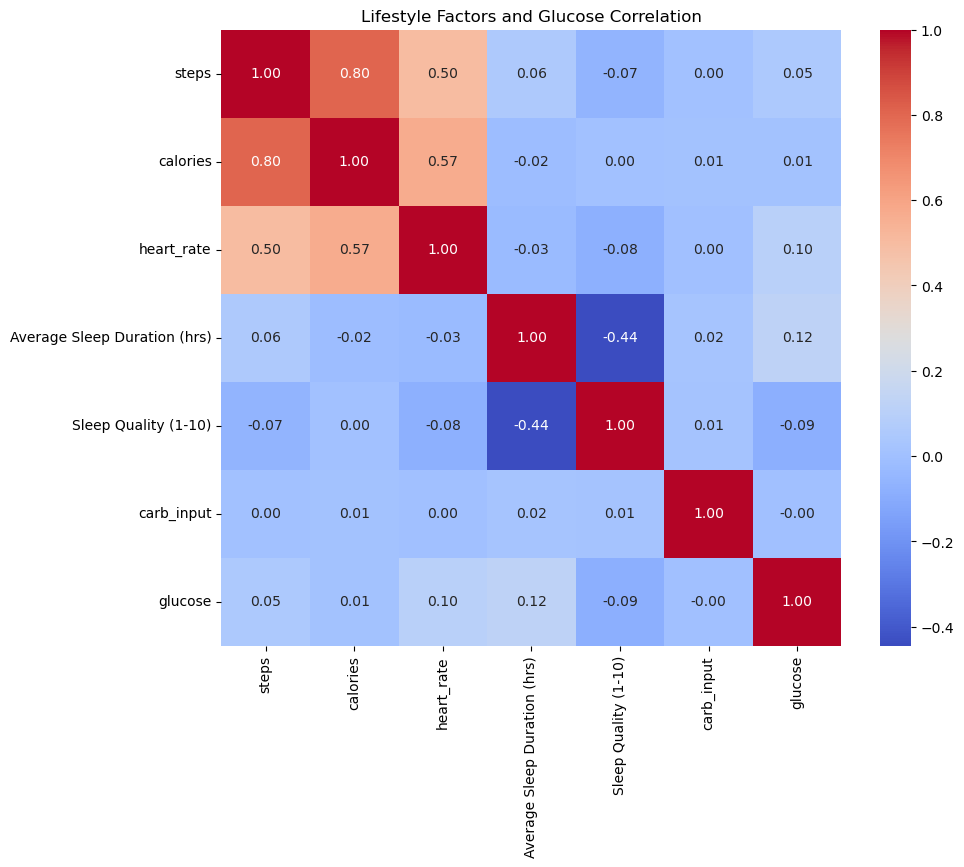

In [24]:
lifestyle_cols = [
    'steps',
    'calories',
    'heart_rate',
    'Average Sleep Duration (hrs)',
    'Sleep Quality (1-10)',
    'carb_input',
    'glucose'
]

corr_matrix = df[lifestyle_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Lifestyle Factors and Glucose Correlation")
plt.show()

# 6.Does Bolus Insulin Effectively Control Meal-Time Glucose?
## Markers Chosen
bolus_volume_delivered
carb_input
glucose
## Why These Markers?
Bolus insulin is administered to offset meal-related glucose spikes.
### This analysis evaluates:
Insulin effectiveness
Meal-time glucose control
Insulin-to-carb balance
Medical Importance
### Improper bolus dosing may lead to:
Hyperglycemia
Hypoglycemia
Poor diabetes management

                        bolus_volume_delivered  carb_input   glucose
bolus_volume_delivered                1.000000    0.169899  0.020115
carb_input                            0.169899    1.000000 -0.001014
glucose                               0.020115   -0.001014  1.000000


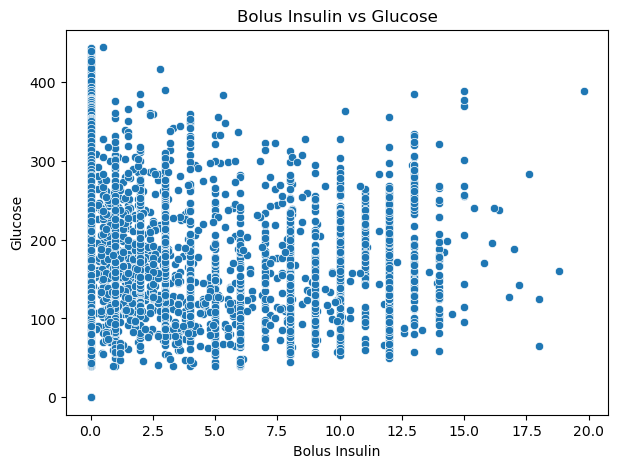

In [25]:
insulin_cols = [
    'bolus_volume_delivered',
    'carb_input',
    'glucose'
]

print(df[insulin_cols].corr())

plt.figure(figsize=(7,5))

sns.scatterplot(
    x='bolus_volume_delivered',
    y='glucose',
    data=df
)

plt.title("Bolus Insulin vs Glucose")
plt.xlabel("Bolus Insulin")
plt.ylabel("Glucose")
plt.show()